Отчет о задержках авиарейсов

Цель: основываясь на статистических данных, выявить характер и особенности задержек авиарейсов. 
Исследуемый датасет - авиарейсы США за 2015 год.

Задержка считается **существенной** если она составляет больше 15 минут. Приведены 2 гистограммы долей задержек в месяц - с какой либо задержкой и с существенной. Видно, что распределение практически не поменялось, и от месяца к месяцу не сильно меняется.

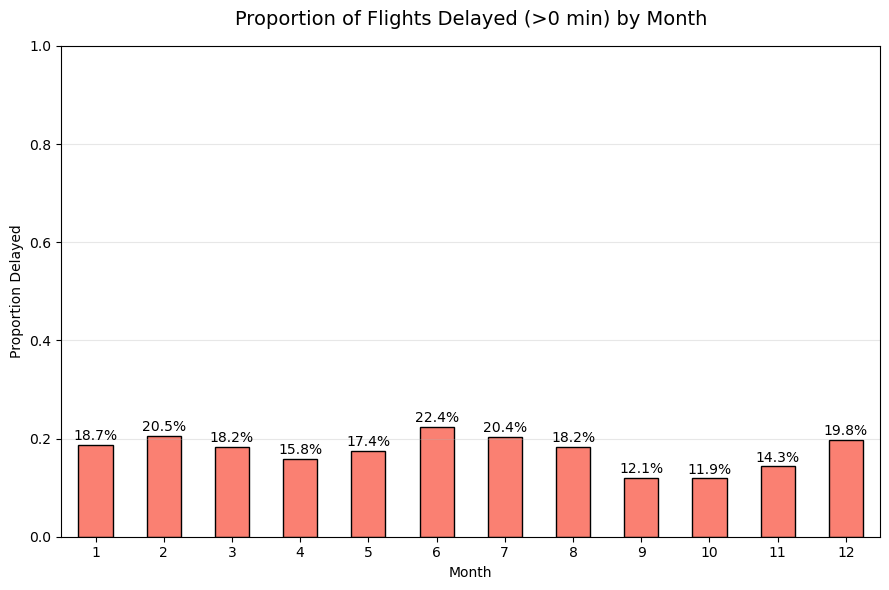

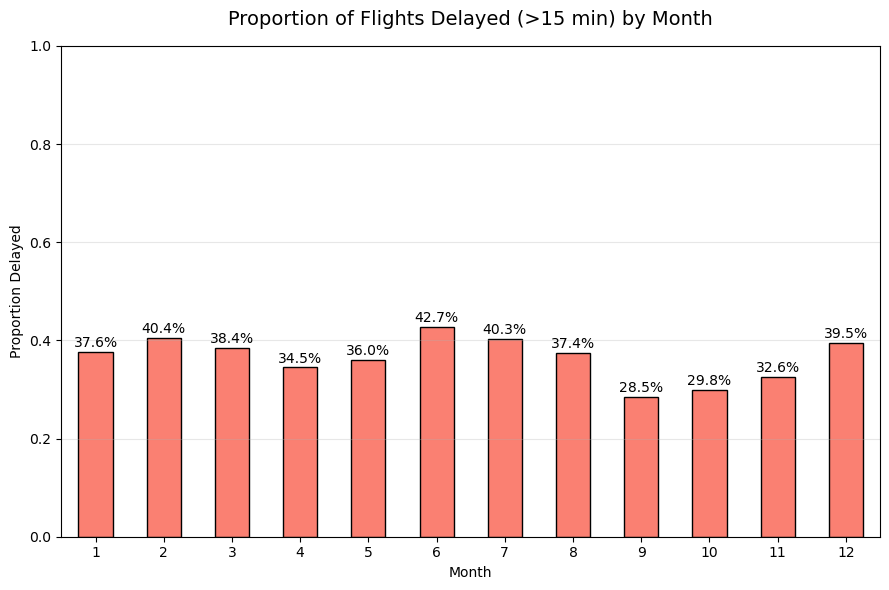

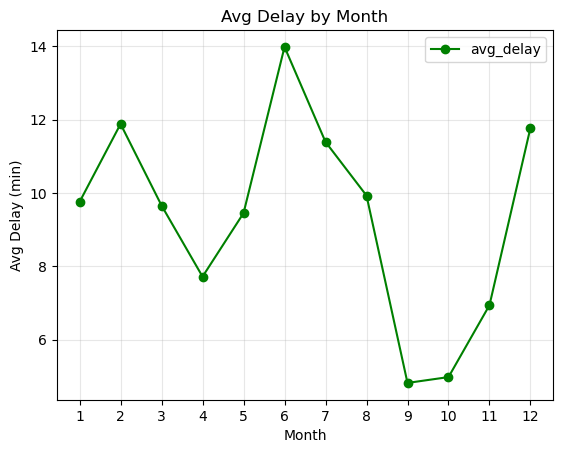

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

airlines = pd.read_csv("flights_dataset/airlines.csv", dtype = str)
airports = pd.read_csv("flights_dataset/airports.csv", dtype = str)
flights = pd.read_csv("flights_dataset/flights.csv", dtype = str)

flights['DATE'] = pd.to_datetime(flights[['YEAR', 'MONTH', 'DAY']])

flights['DEPARTURE_DELAY'] = pd.to_numeric(
    flights['DEPARTURE_DELAY'], errors='coerce'
)

flights['MONTH'] = pd.to_numeric(
    flights['MONTH'], errors='coerce'
)

flights['DAY_OF_WEEK'] = pd.to_numeric(
    flights['DAY_OF_WEEK'], errors='coerce'
)

total_per_month   = flights['MONTH'].value_counts().sort_index()
delayed_per_month = flights.loc[flights['DEPARTURE_DELAY'] > 15, 'MONTH'].value_counts().sort_index()

prop_delayed = delayed_per_month / total_per_month

fig = plt.figure(figsize=(9, 6))
fig.patch.set_facecolor('xkcd:white')

ax = prop_delayed.plot(
    kind='bar',
    color='salmon',
    edgecolor='black',
    ax=plt.gca()
)

ax.set_title('Proportion of Flights Delayed (>0 min) by Month', fontsize=14, pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Proportion Delayed')
ax.set_ylim(0, 1)

for i, v in enumerate(prop_delayed):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

total_per_month   = flights['MONTH'].value_counts().sort_index()
delayed_per_month = flights.loc[flights['DEPARTURE_DELAY'] > 0, 'MONTH'].value_counts().sort_index()

prop_delayed = delayed_per_month / total_per_month

fig = plt.figure(figsize=(9, 6))
fig.patch.set_facecolor('xkcd:white')

ax = prop_delayed.plot(
    kind='bar',
    color='salmon',
    edgecolor='black',
    ax=plt.gca()
)

ax.set_title('Proportion of Flights Delayed (>15 min) by Month', fontsize=14, pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Proportion Delayed')
ax.set_ylim(0, 1)

for i, v in enumerate(prop_delayed):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

monthly = flights.groupby('MONTH').agg(
    avg_delay=('DEPARTURE_DELAY', 'mean'),
    delay_rate=('DEPARTURE_DELAY', lambda x: (x > 15).mean())
).reset_index()

monthly.plot(x='MONTH', y='avg_delay', kind='line', marker='o', color='green')
plt.title('Avg Delay by Month')
plt.xlabel('Month')
plt.ylabel('Avg Delay (min)')
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.show()


Видно, что наиболее объемные по задержкам месяцы - декабрь, феварль, июнь и июль.
Это можно связать с нагрузками в праздники из за большого объема туристических поездок.

Далее мы рассмотрим более точную статистику - график распредления количества задержек и доли задержек по дням с помеченными локальными максимумами. 

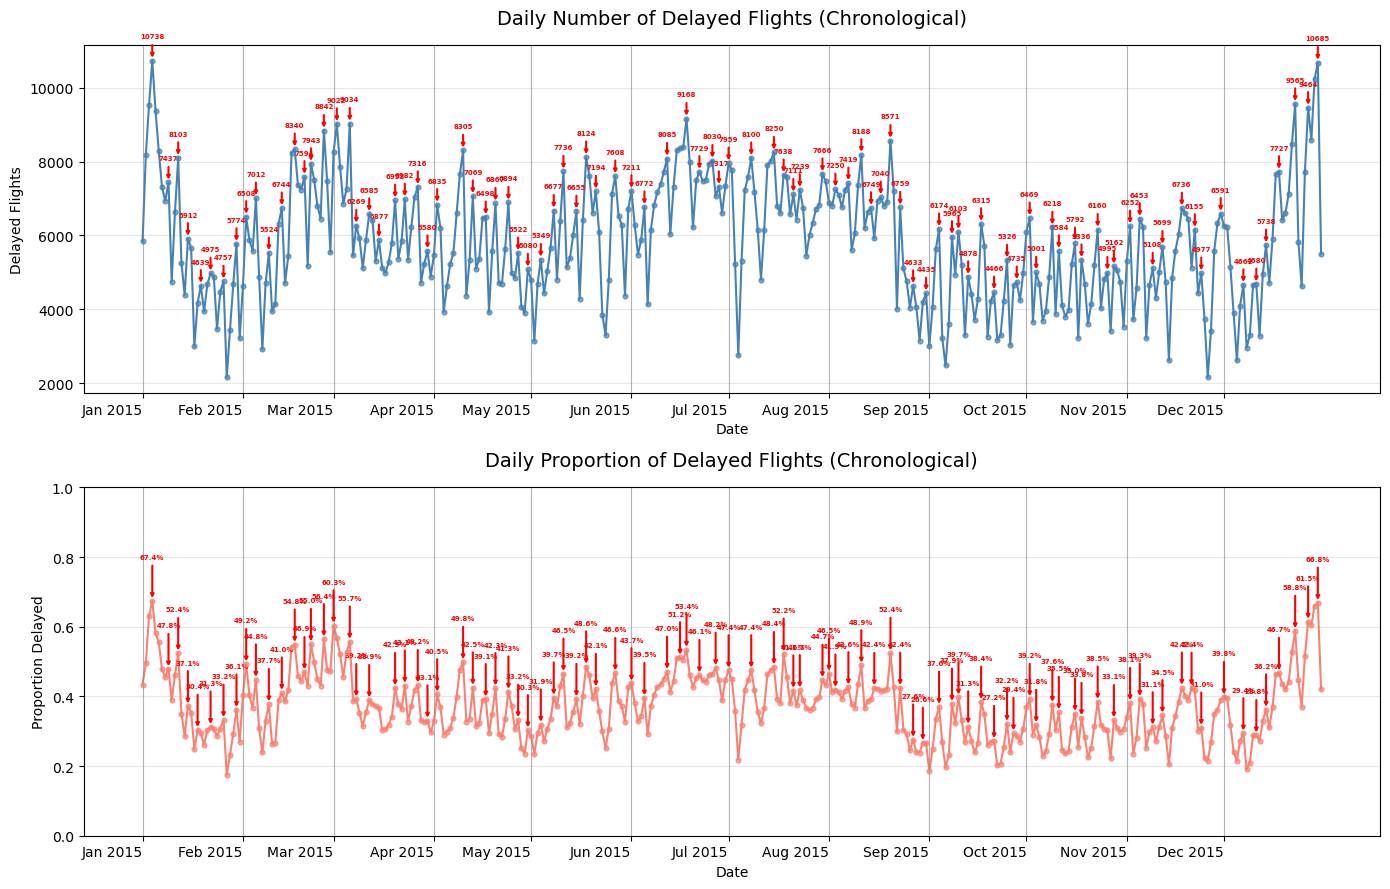

In [41]:
flights['DATE'] = pd.to_datetime(flights[['YEAR', 'MONTH', 'DAY']], errors='coerce')
flights = flights.dropna(subset=['DATE', 'DEPARTURE_DELAY'])

daily = (
    flights
    .groupby('DATE')
    .agg(
        total_flights=('FLIGHT_NUMBER', 'count'),
        delayed_flights=('DEPARTURE_DELAY', lambda s: (s > 0).sum())
    )
    .reset_index()
)

daily['delay_proportion'] = daily['delayed_flights'] / daily['total_flights']

daily = daily.sort_values('DATE').reset_index(drop=True)

def local_maxima(series):
    """Return indices where series[i-1] < series[i] > series[i+1]"""
    maxima = []
    values = series.values
    for i in range(1, len(values) - 1):
        if values[i-1] < values[i] > values[i+1]:
            maxima.append(i)
    return np.array(maxima)

peaks_count = local_maxima(daily['delayed_flights'])
peaks_prop  = local_maxima(daily['delay_proportion'])

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 9))

ax1.plot(daily['DATE'], daily['delayed_flights'],
         color='steelblue', linewidth=1.5, drawstyle='default')
ax1.scatter(daily['DATE'], daily['delayed_flights'],
            color='steelblue', s=12, alpha=0.7, zorder=5)

delta = daily['delayed_flights'].max() - daily['delayed_flights'].min()
for i in peaks_count:
    date = daily['DATE'].iloc[i]
    value = daily['delayed_flights'].iloc[i]
    ax1.annotate(
        f'{value:.0f}',
        xy=(date, value),
        xytext=(date, value + 0.07 * delta),
        arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
        ha='center', fontsize=5, color='red', weight='bold'
    )

ax1.set_title('Daily Number of Delayed Flights (Chronological)', fontsize=14, pad=15)
ax1.set_xlabel('Date')
ax1.set_ylabel('Delayed Flights')
ax1.grid(True, alpha=0.3)

ax2.plot(daily['DATE'], daily['delay_proportion'],
         color='salmon', linewidth=1.5, drawstyle='default')
ax2.scatter(daily['DATE'], daily['delay_proportion'],
            color='salmon', s=12, alpha=0.7, zorder=5)

for i in peaks_prop:
    date = daily['DATE'].iloc[i]
    value = daily['delay_proportion'].iloc[i]
    ax2.annotate(
        f'{value:.1%}',
        xy=(date, value),
        xytext=(date, value + 0.12),
        arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
        ha='center', fontsize=5, color='red', weight='bold'
    )
    

ax2.set_title('Daily Proportion of Delayed Flights (Chronological)', fontsize=14, pad=15)
ax2.set_xlabel('Date')
ax2.set_ylabel('Proportion Delayed')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)
for ax in [ax1, ax2, ax3]:
    first_of_month = daily['DATE'].dt.to_period('M').dt.to_timestamp()
    first_of_month = first_of_month.drop_duplicates().sort_values()

    for date in first_of_month:
        ax.axvline(date, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

    ax.set_xticks(first_of_month)
    ax.set_xticklabels([d.strftime('%b %Y') for d in first_of_month], rotation=0, ha='right')

plt.tight_layout()
plt.show()

Эти графики помогут понять влияют ли праздники на количество задержек.
Заметим, что пики появлются практически периодично, так что взглянем на распрелеление задержок по дням недели.

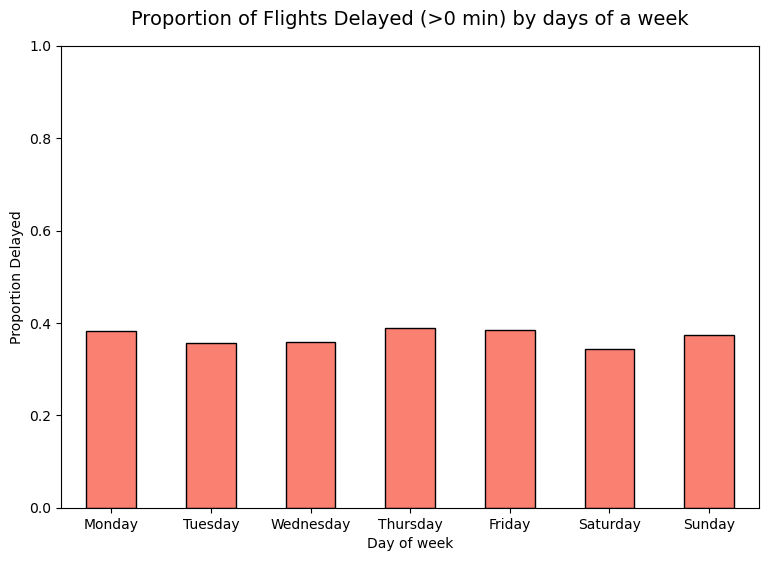

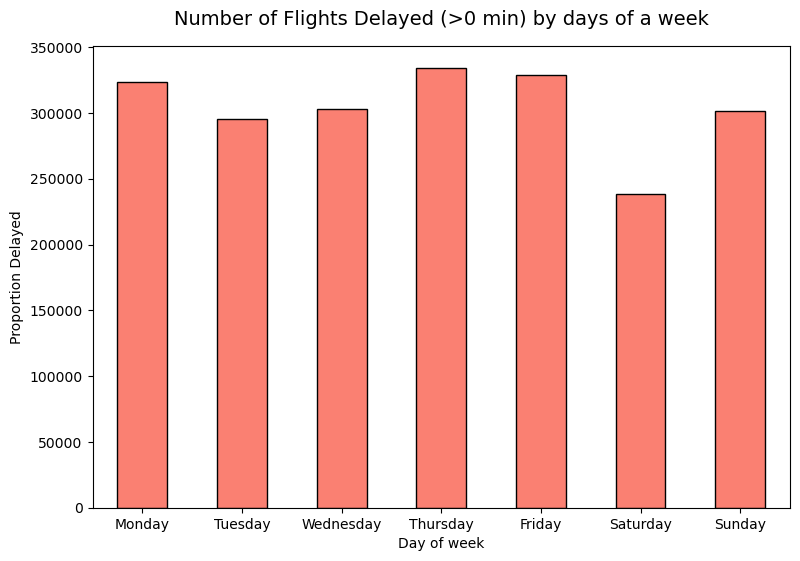

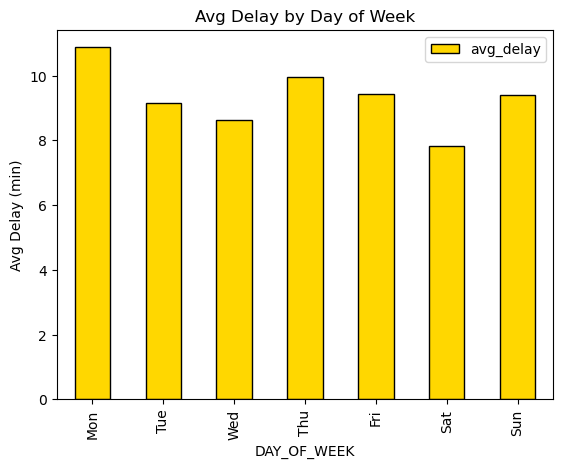

In [7]:
flights = flights.dropna(subset=['DAY_OF_WEEK', 'DEPARTURE_DELAY'])

weekly = (
    flights
    .groupby('DAY_OF_WEEK')
    .agg(
        total_flights=('FLIGHT_NUMBER', 'count'),
        delayed_flights=('DEPARTURE_DELAY', lambda s: (s > 0).sum())
    )
    .reset_index()
)

weekly['delay_proportion'] = weekly['delayed_flights'] / weekly['total_flights']

weekly = weekly.sort_values('DAY_OF_WEEK').reset_index(drop=True)
fig = plt.figure(figsize=(9, 6))
fig.patch.set_facecolor('xkcd:white')

ax = weekly['delay_proportion'].plot(
    kind='bar',
    color='salmon',
    edgecolor='black',
    ax=plt.gca()
)

ax.set_title('Proportion of Flights Delayed (>0 min) by days of a week', fontsize=14, pad=15)
ax.set_xlabel('Day of week', rotation = 0)
ax.set_ylabel('Proportion Delayed')
ax.set_ylim(0, 1)

ax.set_xticklabels(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"], rotation=0, ha='center')

fig = plt.figure(figsize=(9, 6))
fig.patch.set_facecolor('xkcd:white')

ax = weekly['delayed_flights'].plot(
    kind='bar',
    color='salmon',
    edgecolor='black',
    ax=plt.gca()
)

ax.set_title('Number of Flights Delayed (>0 min) by days of a week', fontsize=14, pad=15)
ax.set_xlabel('Day of week', rotation = 0)
ax.set_ylabel('Proportion Delayed')
ax.set_xticklabels(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"], rotation=0, ha='center')

dow_map = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
dow_delay = (
    flights.groupby('DAY_OF_WEEK')
    .agg(avg_delay=('DEPARTURE_DELAY', 'mean'))
    .reset_index()
    .replace({'DAY_OF_WEEK': dow_map})
)

dow_delay.plot(x='DAY_OF_WEEK', y='avg_delay', kind='bar', color='gold', edgecolor='black')
plt.title('Avg Delay by Day of Week')
plt.ylabel('Avg Delay (min)')
plt.show()

Эти данные показывают, что в среднем по дням недели показатели задержек очень похожи, наименьшее значение достигается в субботу.

Тогда подберемся к этой закономерности более аккуратно на примере июля

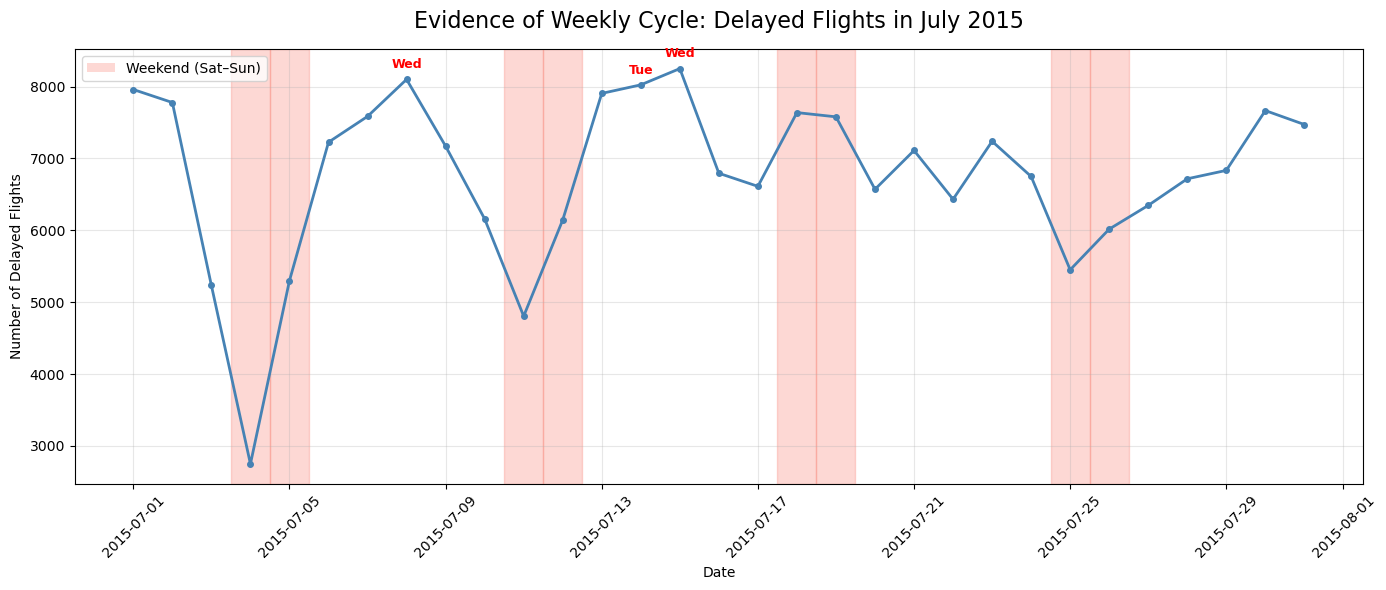

In [70]:
july = daily[(daily['DATE'] >= '2015-07-01') & (daily['DATE'] <= '2015-07-31')].copy()
july['day_of_week'] = july['DATE'].dt.day_name()
july['day_num'] = july['DATE'].dt.day

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(july['DATE'], july['delayed_flights'], 
        color='steelblue', linewidth=2, marker='o', markersize=4)

weekends = july[july['DATE'].dt.weekday >= 5]
for _, row in weekends.iterrows():
    ax.axvspan(row['DATE'] - pd.Timedelta(hours=12), 
               row['DATE'] + pd.Timedelta(hours=12), 
               color='salmon', alpha=0.3)

for idx, row in july.iterrows():
    if row['delayed_flights'] > july['delayed_flights'].quantile(0.9):  # топ 10%
        ax.annotate(row['day_of_week'][:3], 
                    xy=(row['DATE'], row['delayed_flights']),
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=9, color='red', weight='bold')

ax.set_title('Evidence of Weekly Cycle: Delayed Flights in July 2015', fontsize=16, pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Number of Delayed Flights')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='salmon', alpha=0.3, label='Weekend (Sat–Sun)')]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

Заметим, что на примере июля наше предположение подтверждается - правда есть периодичность. В субботу количество задержек гораздо меньше чем в остальные дни. Это может быть связано с рабочим графиком - в субботу гораздо меньше перелетов в целях работы.

Теперь посмотрим на статистику задержек по аэропортам - топ 15 по количеству задержек

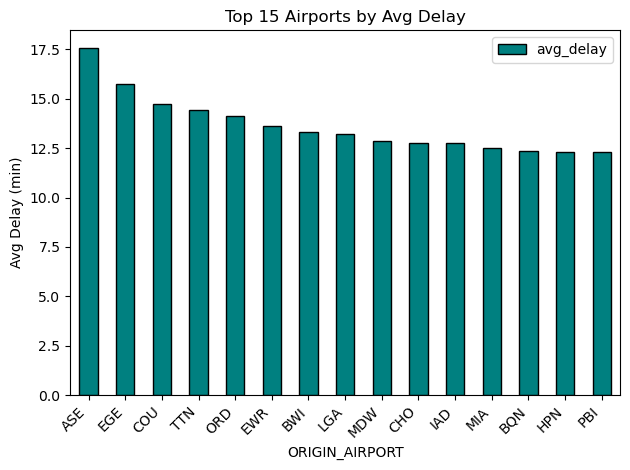

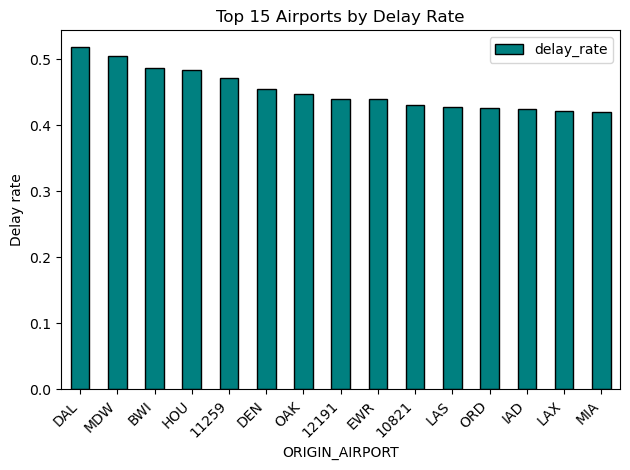

In [4]:
airport_delay = (
    flights.groupby('ORIGIN_AIRPORT')
    .agg(
        avg_delay=('DEPARTURE_DELAY', 'mean'),
        delay_rate=('DEPARTURE_DELAY', lambda x: (x > 0).mean()),
        total_flights=('FLIGHT_NUMBER', 'count')
    )
    .query('total_flights > 1000')
)

airport_delay.sort_values('avg_delay', ascending=False).head(15).plot(y='avg_delay', kind='bar', color='teal', edgecolor='black', title='Top 15 Airports by Avg Delay')
plt.ylabel('Avg Delay (min)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

airport_delay.sort_values('delay_rate', ascending=False).head(15).plot(y='delay_rate', kind='bar', color='teal', edgecolor='black', title='Top 15 Airports by Delay Rate')
plt.ylabel('Delay rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

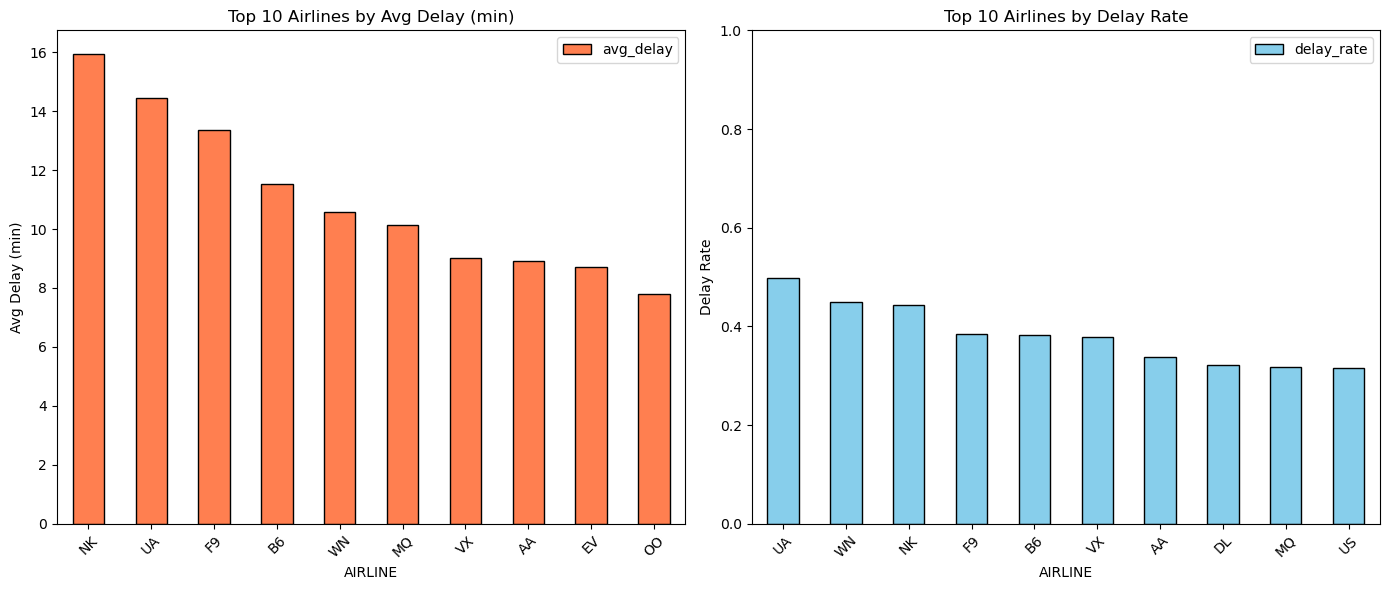

In [5]:
airline_delay = (
    flights.groupby('AIRLINE')
    .agg(
        avg_delay=('DEPARTURE_DELAY', 'mean'),
        delay_rate=('DEPARTURE_DELAY', lambda x: (x > 0).mean()),
        total_flights=('FLIGHT_NUMBER', 'count')
    )
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

airline_delay.sort_values('avg_delay', ascending=False).head(10).plot(y='avg_delay', kind='bar', ax=ax1, color='coral', edgecolor='black')
ax1.set_title('Top 10 Airlines by Avg Delay (min)')
ax1.set_ylabel('Avg Delay (min)')
ax1.tick_params(axis='x', rotation=45)

airline_delay.sort_values('delay_rate', ascending=False).head(10).plot(y='delay_rate', kind='bar', ax=ax2, color='skyblue', edgecolor='black')
ax2.set_title('Top 10 Airlines by Delay Rate')
ax2.set_ylabel('Delay Rate')
ax2.set_ylim(0, 1)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Вывод: Подведя статистику можно сделать вывод, что доля задержек меняется сильно в период новогодних праздников в декбаре - январе. Можно отметить более маленькие периодчные скачки колиества задержок - в будние их больше, чем в выходные, что может быть вызвано рабочим графиком.Так же влияет аэропорт, из которого совершается вылет: NK, UA, F9, B6, WN имеют больше средние задержки по сравнению с другими. Однако не сильно большие в процентном содержании, чем у остальных